In [ ]:
#Below is the code used to generate the plots of the various Poisson Laguerre Flows at different values of alpha.
#When F=Xi, we first precompute the coefficients for a specific alpha and then compute the flow value by summing those.
#When F=Xi_i, we use the closed form from our paper to directly compute the flow values.

In [121]:
%%gp
\\This code that can be used to generate the first 300 coeficients of the expansion of the Laguerre flow for a choice of alpha in tes(n,alpha)
default(realprecision, 500)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
tes(n,a)= 2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12, Phi(x) * x^(2*n)*hypergeom([n+a+1], [n+1/2], -x^2/4))
for(n=0,300, printf("%1.120e \n", tes(n,5/2)))



(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(n,a)->2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12,Phi(x)*x^(2*n)*hypergeom([n+a+1],[n+1/2],-x^2/4))
4.587943297778214410005503398522601213510681725411262065051698306692351331321415862875246617193081651724104931231638232423 e-1 
1.043422300569727262669508741435838574077399175655061488997770929136178132344420584623389078398744752067455090725152369048 e-2 
2.210734234458783409567408887385080561681826984825694873465380531042616290926885239800623247259906654245753135200005691193 e-4 
4.412054303608586138685698549529482673684352099114401397655665967627812297117903623266883844289848168207592880733934871545 e-6 
8.358973775318871970026873389320229561691814732320398057023811909506371127609558523454894600165566916565633971670298872293 e-8 
1.512156129700251820776652817127958035932110497268112399071117984228109093076795712877710643709815757907655019732433873539 e-9 
2.6238348236372134564852961639583925261291305237

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 25.596691 versus formula: 25.596240 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


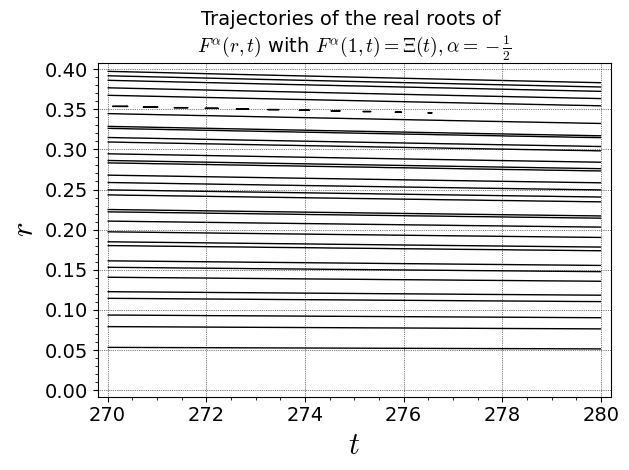

In [629]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("-0.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffam1d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 1)-Xi(60)))
am1d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,270,280),(r,0,0.4),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=500)
show(am1d2,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 25.536717 versus formula: 25.536267 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


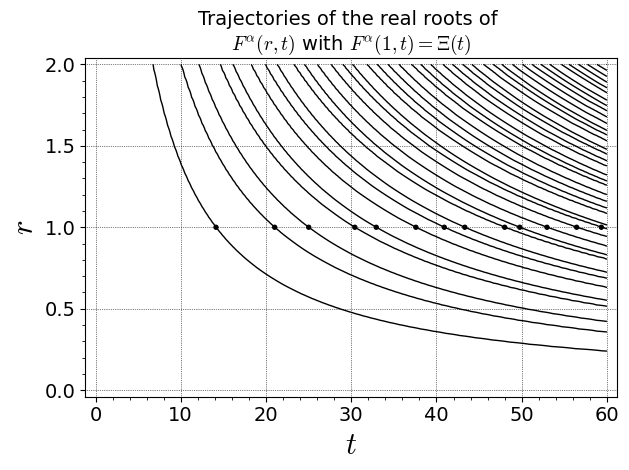

In [630]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("1")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa1.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 1)-Xi(60)))
a1n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t)$',gridlines=True,plot_points=150)
show(a1n+z,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 24.936977 versus formula: 24.936527 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


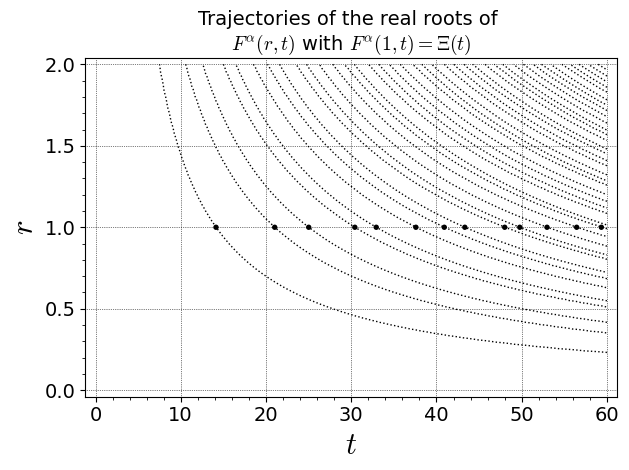

In [631]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("16")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa16.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 1)-Xi(60)))
a16n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t)$',gridlines=True,plot_points=150)
show(a16n+z,aspect_ratio='automatic')

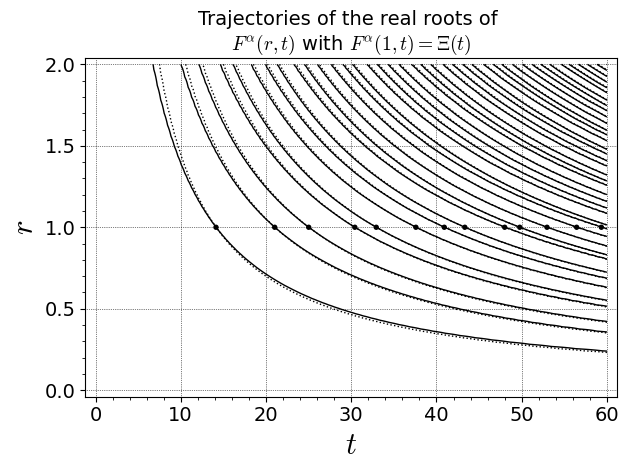

In [632]:
show(a1n+a16n+z,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 17.281111 versus formula: 17.280661 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


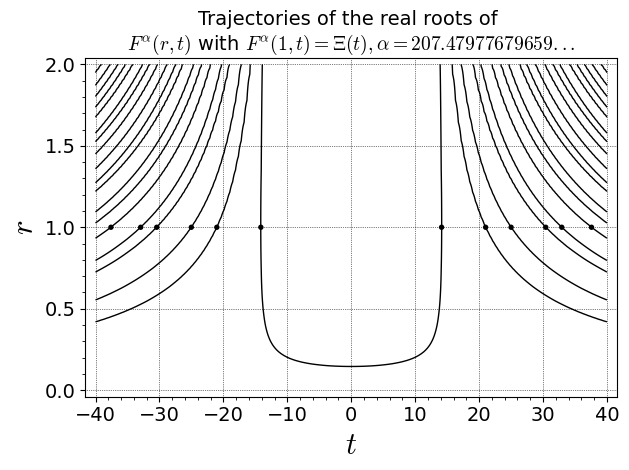

In [633]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 40:
            ord.append([y,1])
            ord.append([-y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("207.47977679659714232")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa207.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 1)-Xi(60)))
a207n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,-40,40),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t), \alpha=207.47977679659...$',gridlines=True,plot_points=180)
show(a207n + z,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 7.293050 versus formula: 7.292600 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


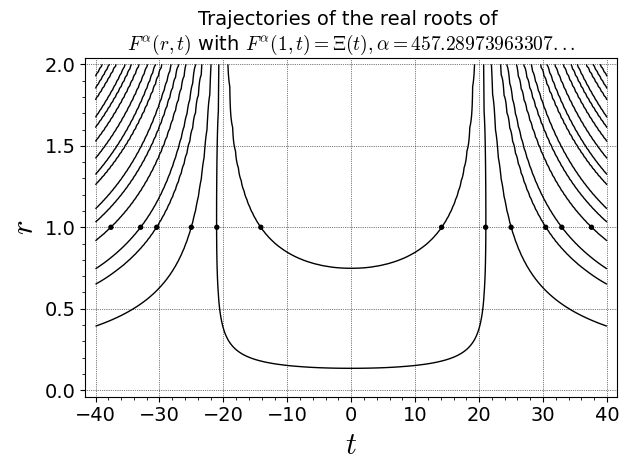

In [634]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 40:
            ord.append([y,1])
            ord.append([-y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("457.28973963307063695")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa457.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 1)-Xi(60)))
a457n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,-40,40),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t), \alpha=457.28973963307...$',gridlines=True,plot_points=180)
show(a457n + z,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -337.249698 versus formula: -337.250176 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


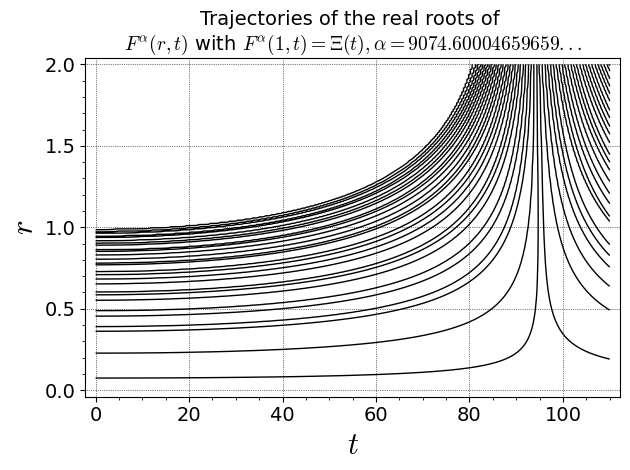

In [635]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("9074.6000465965965587")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa9074.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(100, 1)-Xi(100)))
a9074n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,110),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t), \alpha=9074.60004659659...$',gridlines=True,plot_points=300)
show(a9074n,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -342.153756 versus formula: -342.154235 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


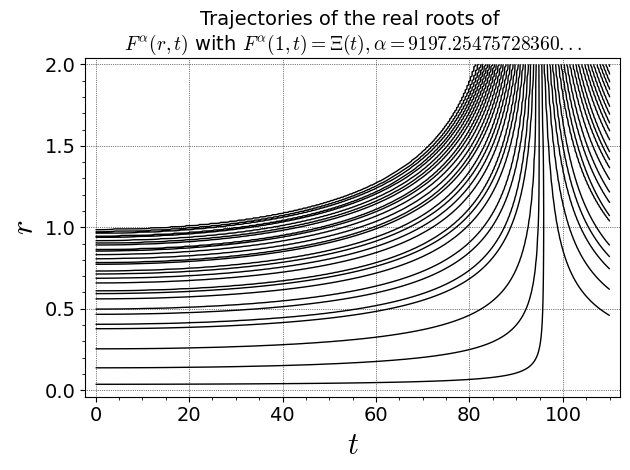

In [636]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("9197.2547572836030293")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa9197.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(r).pow(2*n)*CCF(str(m1[n]))*LagPol(t,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,1)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(100, 1)-Xi(100)))
a9197n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,110),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t), \alpha=9197.25475728360...$',gridlines=True,plot_points=300)
show(a9197n,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 18.823030 versus formula: 18.823030 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


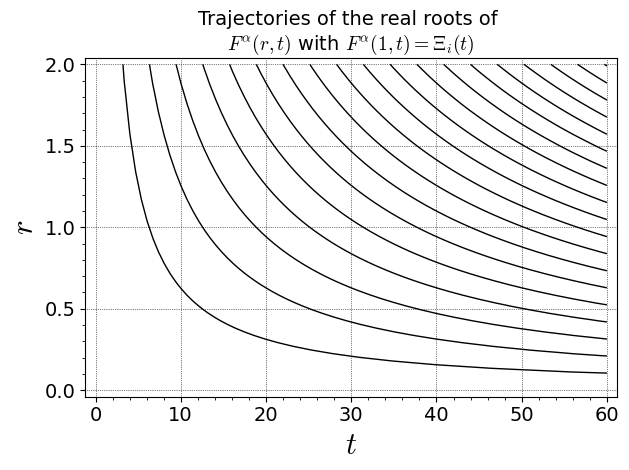

In [637]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)

#set alpha once here:
global alpha
alpha = CCF("1")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert Phi_3 series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i1=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t)$',gridlines=True,plot_points=90)
show(a1i1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 18.027255 versus formula: 18.027255 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


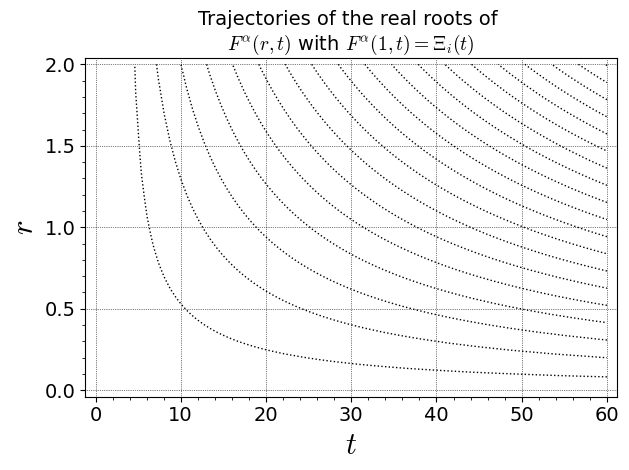

In [638]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)

#set alpha once here:
global alpha
alpha = CCF("16")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i16=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t)$',gridlines=True,plot_points=90)
show(a1i16,aspect_ratio='automatic')

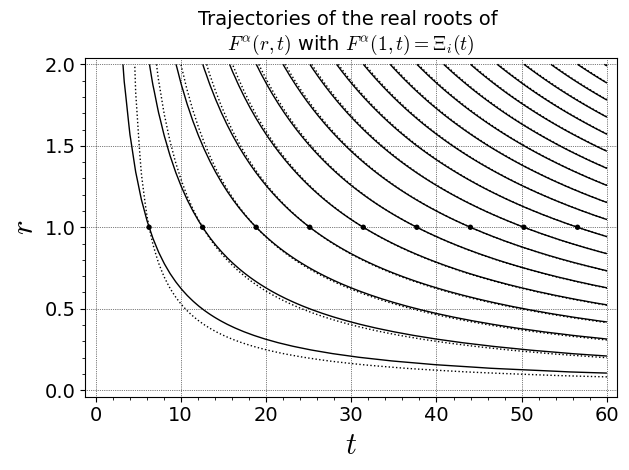

In [639]:
show(a1i1+a1i16+z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 16.755161 versus formula: 16.755161 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


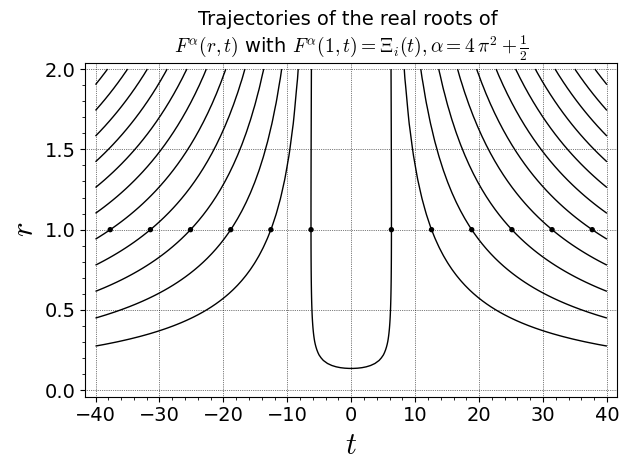

In [661]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(6):
    ord.append([2*pi()*(y+1),1])
    ord.append([-2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = CCF(4*pi()^2+ 0.5)

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i4pi=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,-40,40),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = 4\,\pi^2 + \frac{1}{2}$',gridlines=True,plot_points=120)
show(a1i4pi + z1,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 10.471975 versus formula: 10.471976 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


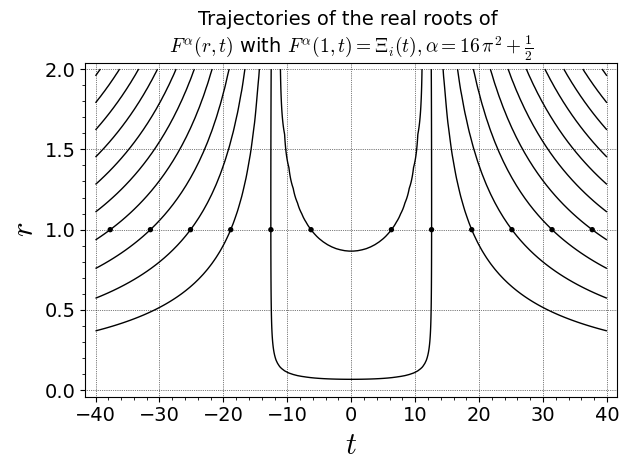

In [660]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(6):
    ord.append([2*pi()*(y+1),1])
    ord.append([-2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(200)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = CCF(16*pi()^2+0.5)

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)
def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i16pi=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,-40,40),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = 16\,\pi^2 + \frac{1}{2}$',gridlines=True,plot_points=120)
show(a1i16pi + z1,aspect_ratio='automatic')

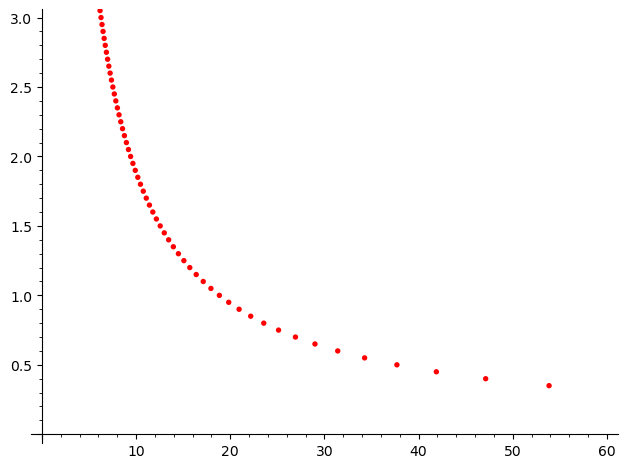

In [642]:
var("r");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
ord = []
r = 0
while r < 3:
    r = r + 0.05
    ord.append([2*3*pi()/r,r])
z2=list_plot(ord, size=15, marker="o", color = "red",xmin=0,xmax=60,ymin=0,ymax=3)
z2

Automated checks:
d/dr z_3(0) via Newton approximation : 18.849556 versus formula: 18.849556 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


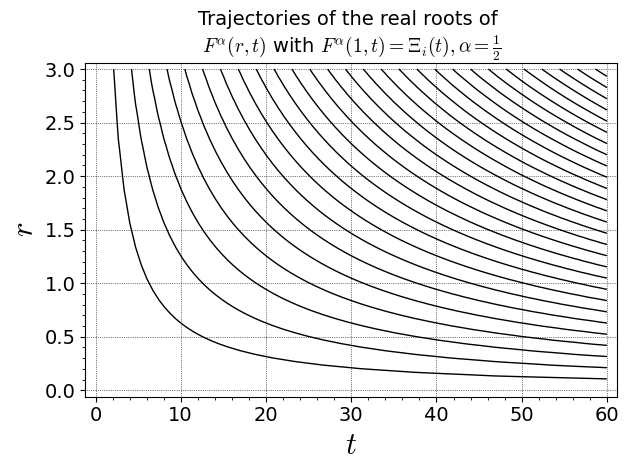

In [663]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = CCF("0.5")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i1d2=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,60),(r,0,3),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = \frac{1}{2}$',gridlines=True,plot_points=90)
show(a1i1d2,aspect_ratio='automatic')

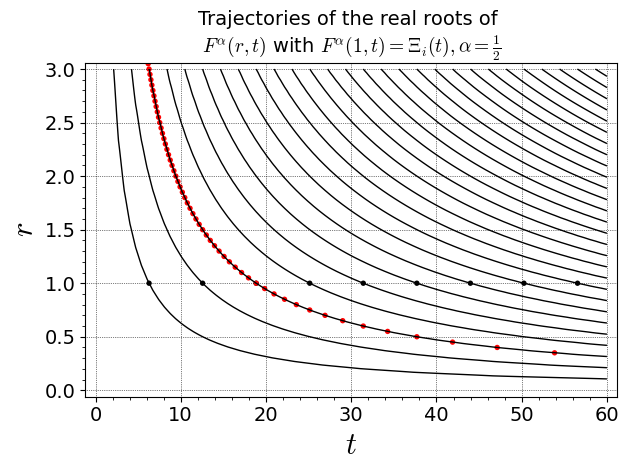

In [644]:
show(a1i1d2 + z1 + z2,aspect_ratio='automatic')

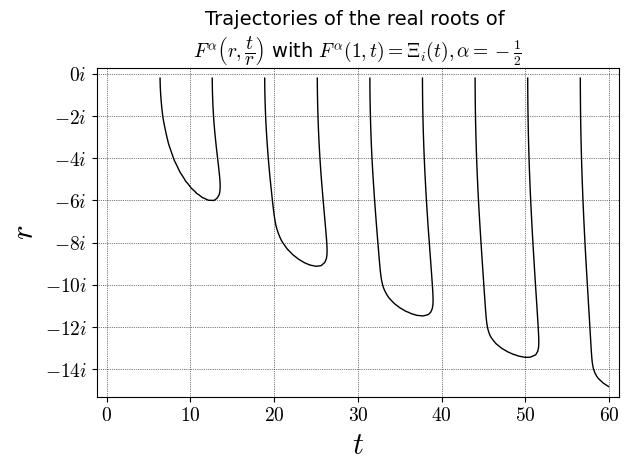

In [645]:
#Laguerre flow closed form for a = -1/2 and F=Xi_i
DRF=RealBallField(300)
CCF=ComplexBallField(300)

def prefact(r):
    pi = DRF.pi()
    r2m1 = CCF(r).pow(2) - 1
    return pi.sqrt() / CCF(r2m1).sqrt()

def expfact(t, r):
    t1 = CCF(t).pow(2) * CCF(r).pow(2) / (CCF(r).pow(2) - 1)
    return t1.exp()

def erfip (t,r):
    r2m1 = CCF(r).pow(2) - 1  
    t1 = CCF(0,1)*(r2m1 + 4 * CCF(0,1) * CCF(r) * CCF(t)) / (DRF("4")*r2m1.sqrt())
    return t1.erf()

def erfin (t,r):
    r2m1 = CCF(r).pow(2) - 1  
    t1 = CCF(0,1)*(r2m1 - 4 * CCF(0,1) * CCF(r) * CCF(t)) / (DRF("4")*r2m1.sqrt())
    return t1.erf()

def LaguerreFlow(t,r):
    r1 = CCF(r)*CCF(0,1)
    t1 = CCF(t)/CCF(r1)
    return (-CCF(0,1)*prefact(r1) * expfact(t1,r1) * (erfip(t1,r1) + erfin(t1,r1))).mid()

xt = [10 * k for k in range(0,7)]
xt_lbl = ['$0$', '$10$', '$20$', '$30$', '$40$', '$50$', '$60$']
yt = [2 * k for k in range(-7, 1)]
yt_lbl = ['$-14i$', '$-12i$', '$-10i$', '$-8i$', '$-6i$', '$-4i$', '$-2i$', '$0i$']

a1new=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-15,0),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)
show(a1new,aspect_ratio='automatic')

In [32]:
%%gp
default(realprecision, 21)
\\ Define OO(x)
OO(x) = 2 * sum(n = 1, 12, (2*Pi^2*n^4*exp(9*x/2) - 3*Pi*n^2*exp(5*x/2)) * exp(-Pi*n^2*exp(2*x)))

F(t, a, r) = 2*cos(Pi*a)*exp((r^2 - 1)/16) / Pi * intnum(s = 0, 1, (1 - s)^(-1/2 + a) / s^(1/2 + a) * exp((1 - r^2)*s/16)* intnum(u = 0, 0.5, exp((r^2 - 1)*s*u^2/4) * cos(t*r*u)))

F(2, 0, 0.5)



(x)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*x/2)-3*Pi*n^2*exp(5*x/2))*exp(-Pi*n^2*exp(2*x)))
(t,a,r)->2*cos(Pi*a)*exp((r^2-1)/16)/Pi*intnum(s=0,1,(1-s)^(-1/2+a)/s^(1/2+a)*exp((1-r^2)*s/16)*intnum(u=0,0.5,exp((r^2-1)*s*u^2/4)*cos(t*r*u)))
0.929690419748681841552


Automated checks:
d/dr z_3(0) via Newton approximation : 18.823030 versus formula: 18.823030 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


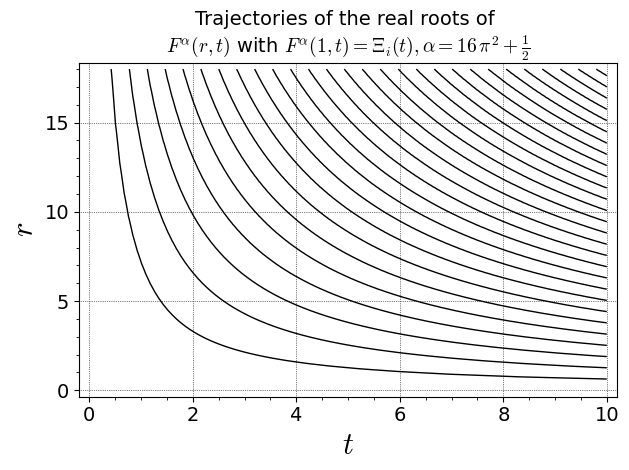

In [5]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(6):
    ord.append([2*pi()*(y+1),1])
    ord.append([-2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(200)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = 1

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)
def LaguerreFlow(t, r):
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(r).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(r)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,10),(r,0,18),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = 16\,\pi^2 + \frac{1}{2}$',gridlines=True,plot_points=120)
show(a1i,aspect_ratio='automatic')

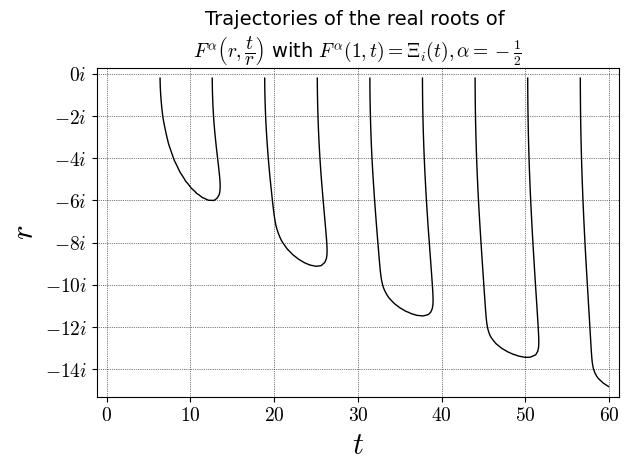

In [6]:
#Laguerre flow closed form for a = -1/2 and F=Xi_i
DRF=RealBallField(300)
CCF=ComplexBallField(300)

def prefact(r):
    pi = DRF.pi()
    r2m1 = CCF(r).pow(2) - 1
    return pi.sqrt() / CCF(r2m1).sqrt()

def expfact(t, r):
    t1 = CCF(t).pow(2) * CCF(r).pow(2) / (CCF(r).pow(2) - 1)
    return t1.exp()

def erfip (t,r):
    r2m1 = CCF(r).pow(2) - 1  
    t1 = CCF(0,1)*(r2m1 + 4 * CCF(0,1) * CCF(r) * CCF(t)) / (DRF("4")*r2m1.sqrt())
    return t1.erf()

def erfin (t,r):
    r2m1 = CCF(r).pow(2) - 1  
    t1 = CCF(0,1)*(r2m1 - 4 * CCF(0,1) * CCF(r) * CCF(t)) / (DRF("4")*r2m1.sqrt())
    return t1.erf()

def LaguerreFlow(t,r):
    r1 = CCF(r)*CCF(0,1)
    t1 = CCF(t)/CCF(r1)
    return (-CCF(0,1)*prefact(r1) * expfact(t1,r1) * (erfip(t1,r1) + erfin(t1,r1))).mid()

xt = [10 * k for k in range(0,7)]
xt_lbl = ['$0$', '$10$', '$20$', '$30$', '$40$', '$50$', '$60$']
yt = [2 * k for k in range(-7, 1)]
yt_lbl = ['$-14i$', '$-12i$', '$-10i$', '$-8i$', '$-6i$', '$-4i$', '$-2i$', '$0i$']

am12i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-15,0),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)
show(am12i,aspect_ratio='automatic')

Automated checks:


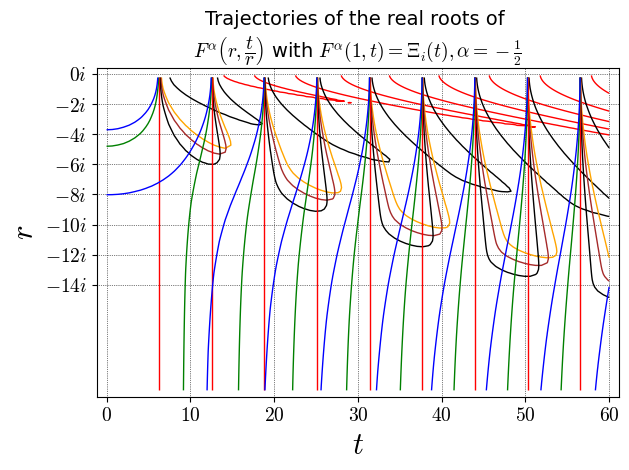

In [164]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(6):
    ord.append([2*pi()*(y+1),1])
    ord.append([-2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(200)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = CCF("-0.5")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert series expressed as finite series of 1F1s
CCF=ComplexBallField(200)
def LaguerreFlow(t, r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sumn=(CCF(0));
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rr).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(tr)*CCF(rr)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn.mid()

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
#print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,I)-Xin(60)))

xt = [10 * k for k in range(0,7)]
xt_lbl = ['$0$', '$10$', '$20$', '$30$', '$40$', '$50$', '$60$']
yt = [2 * k for k in range(-7, 1)]
yt_lbl = ['$-14i$', '$-12i$', '$-10i$', '$-8i$', '$-6i$', '$-4i$', '$-2i$', '$0i$']

am12i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("-150.5")
am3012i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='red',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=210)

global alpha
alpha = CCF("-15.5")
am312i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("-2.5")
am52i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='orange',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("-1.5")
am32i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='brown',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("0.5")
a12i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='red',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("1.5")
a32i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='green',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

global alpha
alpha = CCF("2.5")
a52i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,-21,0),color='blue',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

show(am3012i + am312i + am52i + am32i + am12i + a12i + a32i +a52i,aspect_ratio='automatic')

1.00375422101075105101377407398031358760179017265368671018390208106140928503032616490751393


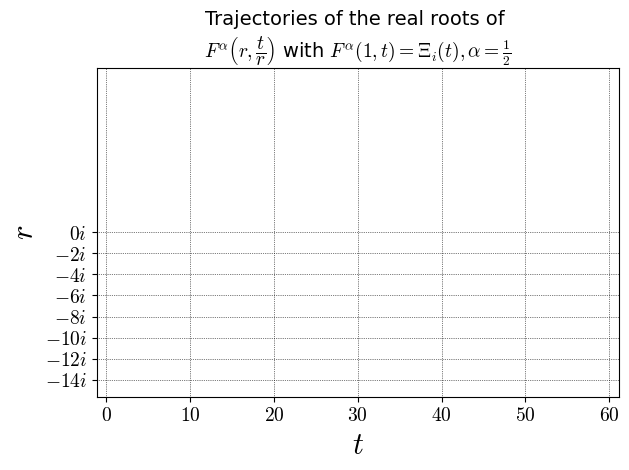

In [103]:
#Laguerre flow closed form for a = 1/2 and F=Xi_i
DRF=RealBallField(300)
CCF=ComplexBallField(300)

#alpha = CCF("0.5")

def prefact(r):
    pi = DRF.pi()
    r2m1 = CCF(r).pow(2) - 1
    return CCF(r2m1 / 16).exp

def Xin(t, r):
    Xin= 2 * (CCF(0,1) * r * t / 2).sin() / (CCF(0,1) * r * t)
    return CCF(Xin).abs()

def LaguerreFlow(t, r):
    return (Xin(CCF(t), CCF(r))).mid()

print(LaguerreFlow(2,-0.15))

xt = [10 * k for k in range(0,7)]
xt_lbl = ['$0$', '$10$', '$20$', '$30$', '$40$', '$50$', '$60$']
yt = [2 * k for k in range(-7, 1)]
yt_lbl = ['$-14i$', '$-12i$', '$-10i$', '$-8i$', '$-6i$', '$-4i$', '$-2i$', '$0i$']

am12i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0.01,60),(r,-15,15),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = \frac{1}{2}$',gridlines=True,plot_points=210)
show(am12i,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : -18.902608 versus formula: 18.902608 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


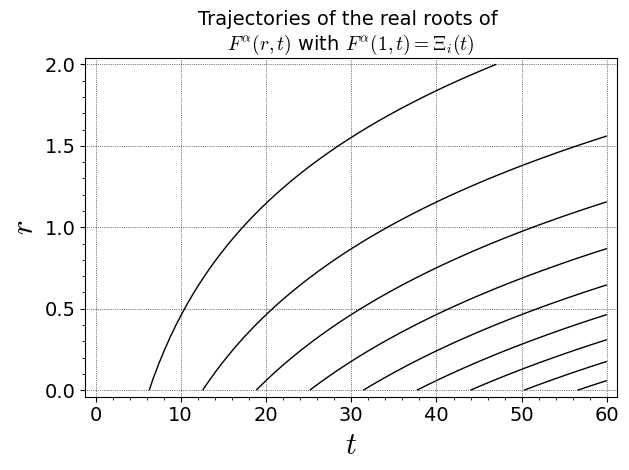

In [109]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)

#set alpha once here:
global alpha
alpha = CCF("-0.5")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert Phi_3 series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    rho = CCF(-r).exp()
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rho).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(rho)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,0+tr) - LaguerreFlow(x0,0+tr))/(tr*100)
        h = LaguerreFlow(x0,0+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,0)-Xin(60)))

a1i1=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t)$',gridlines=True,plot_points=90)
show(a1i1,aspect_ratio='automatic')

In [122]:
#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 10;
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,CCF("0.457090822257524")+tr) - LaguerreFlow(x0,CCF("0.457090822257524")+tr))/(tr*100)
        h = LaguerreFlow(x0,CCF("0.457090822257524")+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - 10)/(tr) 
    print(x1)
    return dzdr3

dzdrzk(3)


[10.00000010102306934329328386323410221015744816122371059984 +/- 6.66e-57]


[10.102306934329328386323410221015744816122371059984 +/- 6.66e-49]

In [134]:
#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 60;
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,CCF("0.0392646840766667247")+tr) - LaguerreFlow(x0,CCF("0.0392646840766667247")+tr))/(tr*100)
        h = LaguerreFlow(x0,CCF("0.0392646840766667247")+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = (x1 - 10)/(tr) 
    print(x1)
    return dzdr3

dzdrzk(3)

KeyboardInterrupt: 

In [127]:
LaguerreFlow(6*pi, 0)

[-0.0052749699758262067656550984388680384499725263822311756 +/- 2.99e-56]

In [229]:
def LaguerreFlow12(t, r):
    sumn=(CCF(0));
    #rho = CCF(-r).exp()
    rho = r
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rho).pow(2)-1)/16).hypergeometric([CCF(CCF("0.5") + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(rho)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

def LaguerreFlow32(t, r):
    sumn=(CCF(0));
    #rho = CCF(-r).exp()
    rho = r
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rho).pow(2)-1)/16).hypergeometric([CCF(CCF("1.5") + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(rho)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

def LaguerreFlowm12(t, r):
    sumn=(CCF(0));
    #rho = CCF(-r).exp()
    rho = r
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rho).pow(2)-1)/16).hypergeometric([CCF(CCF("-0.5") + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(rho)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

def LaguerreFlowm12diff(t, r):
    tp = CCF("0.0000000000001")
    return (LaguerreFlowm12(t + tp, r)- LaguerreFlowm12(t, r)) / tp

def LaguerreFlowm12diff1(t, r):
    return (LaguerreFlow12(t, r)- LaguerreFlowm12(t, r)) * 2 * CCF(r).pow(2) * CCF(t) / (CCF(r).pow(2)-1)

print(LaguerreFlowm12diff(4*pi/-6.011635512*I,CCF(0,-6.011635512)))
print("\n")
print(LaguerreFlowm12diff1(4*pi/-6.011635512*I,CCF(0,-6.011635512)))
print("\n")
print(LaguerreFlow12((4*pi)/-6.011635512*I,CCF(0,-6.011635512)))

[-9.5509501532357792793659094556e-15 +/- 6.04e-44] + [-2.13702666976558389423625837276421794496684933e-12 +/- 6.72e-57]*I


[2.13702666976558518938221439168320941845331589e-12 +/- 6.90e-57]*I


[-6.74502086728976573781391319879657759422e-18 +/- 2.97e-57]


Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -57767697.029099 versus formula: 25.596240 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


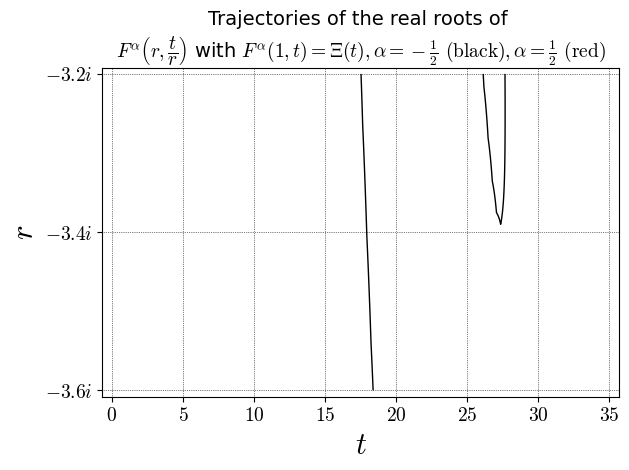

In [147]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("-0.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffam1d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

xt = [5 * k for k in range(0,8)]
xt_lbl = ['$0$', '$5$', '$10$', '$15$','$20$', '$25$', '$30$', '$35$']
yt = [k / 10 for k in range(-36,-30,2)]
yt_lbl = ['$-3.6i$', '$-3.4i$', '$-3.2i$']

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
am1d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,35),(r,-3.6,-3.2),color='black',fontsize=14,linestyle ="-",linewidth=1,ticks=[xt, yt], tick_formatter = [xt_lbl, yt_lbl],axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' + r'$F^{\alpha}\left(r,\dfrac{t}{r}\right)$' ' with ' r'$F^\alpha(1,t) = \Xi(t), \alpha = -\frac{1}{2}\text{ (black)},\alpha = \frac{1}{2}\text{ (red)}$',gridlines=True,plot_points=120)
show(am1d2,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -53765604.720281 versus formula: 25.556258 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


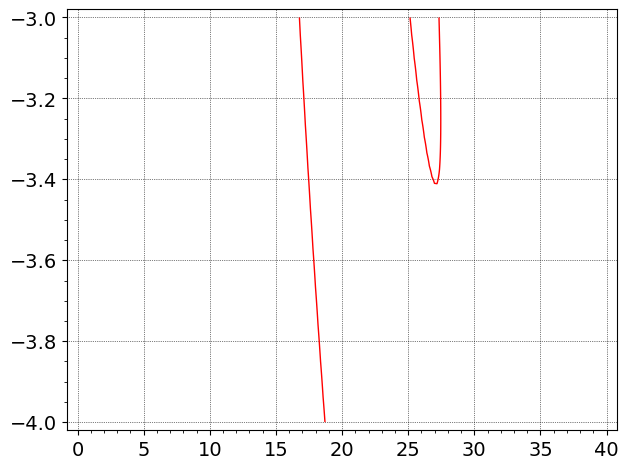

In [103]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("0.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa1d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
a1d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='red',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=210)
show(a1d2,aspect_ratio='automatic')

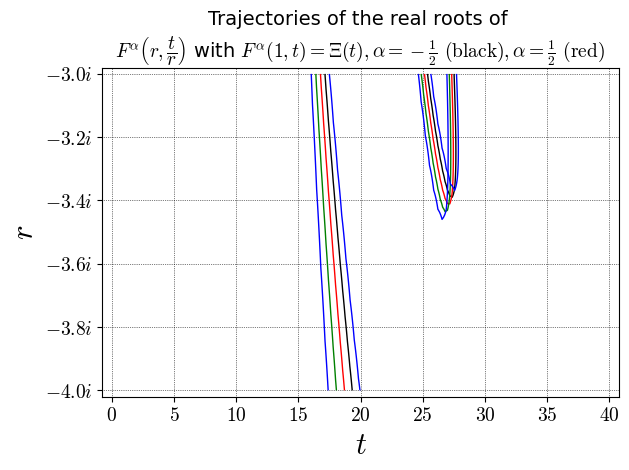

In [132]:
show(am1d2 + a1d2 + a3d2 + a5d2 + am3d2,aspect_ratio='automatic') 

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -49757223.237787 versus formula: 25.516275 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


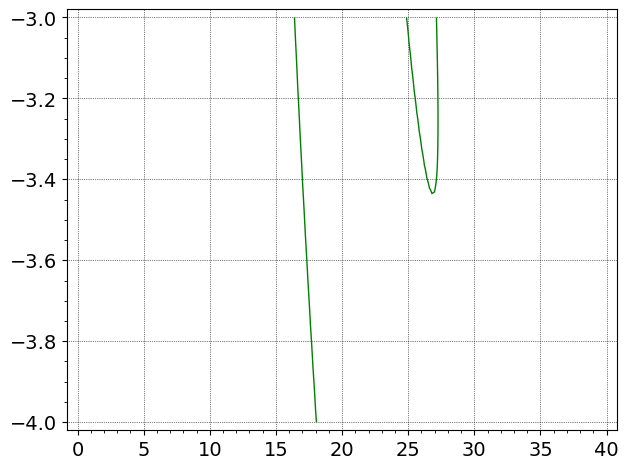

In [122]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("1.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa3d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
a3d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='green',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=210)
show(a3d2,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -45742522.893279 versus formula: 25.476293 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


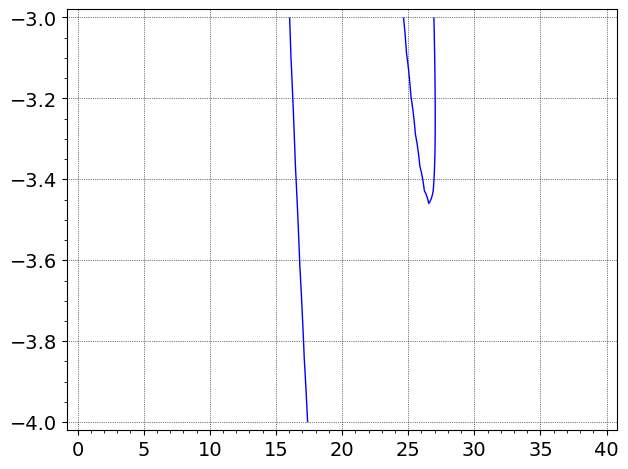

In [126]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("2.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa5d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
a5d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='blue',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=120)
show(a5d2,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : -61763529.620683 versus formula: 25.636223 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


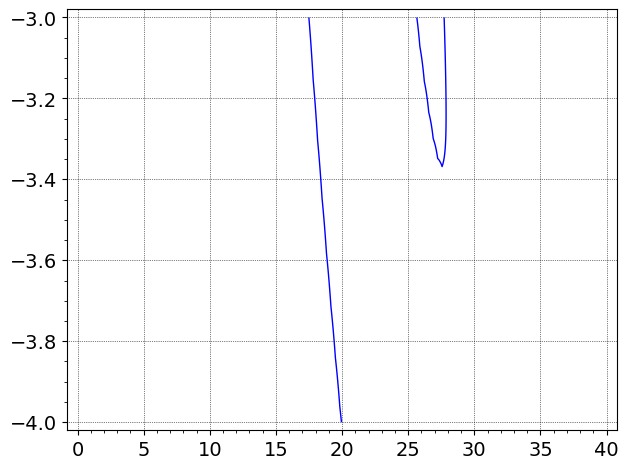

In [127]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("-1.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffam3d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
am3d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='blue',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=120)
show(am3d2,aspect_ratio='automatic')

In [123]:
%%gp
\\This code that can be used to generate the first 300 coeficients of the expansion of the Laguerre flow for a choice of alpha in tes(n,alpha)
default(realprecision, 500)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
tes(n,a)= 2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12, Phi(x) * x^(2*n)*hypergeom([n+a+1], [n+1/2], -x^2/4))
for(n=0,300, printf("%1.120e \n", tes(n,-3/2)))



(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(n,a)->2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12,Phi(x)*x^(2*n)*hypergeom([n+a+1],[n+1/2],-x^2/4))
5.028332097005119525949164819927071572765175971378094620787382452064218858686981568550491765893722423977459221050584855284 e-1 
1.136436346976624572834737047369915350606494147820770773674413964625706671406204486822415167952761444399676129944621772875 e-2 
2.395887246535494197395736341790030079912740391216376722747418096859356861187396959120150784880999685943073262461825129120 e-4 
4.762075327972160874548546536711657863371076397058251267932535597445866961616825428900694996099820841556308907068858245340 e-6 
8.990976506344408409213542240668231618138700598234483142333211568347082563803161560415710218002245199749404138898442948821 e-8 
1.621637645388395088739844601048758645524471037714050634998726516035389970935546811876844354115813671035513178801624898752 e-9 
2.8064418453791163587550315780767886740797421607

In [124]:
%%gp
\\This code that can be used to generate the first 300 coeficients of the expansion of the Laguerre flow for a choice of alpha in tes(n,alpha)
default(realprecision, 500)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
tes(n,a)= 2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12, Phi(x) * x^(2*n)*hypergeom([n+a+1], [n+1/2], -x^2/4))
for(n=0,300, printf("%1.120e \n", tes(n,31/2)))



(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(n,a)->2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12,Phi(x)*x^(2*n)*hypergeom([n+a+1],[n+1/2],-x^2/4))
3.391891750011955791420307558210849176084864363671653024514912102783786893089615565684873610335327251500319992938726054246 e-1 
7.881550234561364430610012979641486939984712961487967364119849423859385403740919391546064764621698210186409371216661586991 e-3 
1.698224486870470607470559977764483828440617608899388027817158061488696792919249603616492814438115380037163256418695698481 e-4 
3.436136182023410330209769732991127313762183011710950046909918038475565969506484785453181396718189987505487640974943460296 e-6 
6.585786631868941084636396401169083511517620202002710773770823967489577191540694236951009664640140418682117067936152973199 e-8 
1.203298522174491140844550826705459496325397460637126713292298407857156069051863955308208259795889898431241244134480826979 e-9 
2.1061679918002359709467068762759761978578684402

In [125]:
%%gp
\\This code that can be used to generate the first 300 coeficients of the expansion of the Laguerre flow for a choice of alpha in tes(n,alpha)
default(realprecision, 500)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
tes(n,a)= 2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12, Phi(x) * x^(2*n)*hypergeom([n+a+1], [n+1/2], -x^2/4))
for(n=0,300, printf("%1.120e \n", tes(n,33/2)))



(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(n,a)->2*gamma(n+1)/gamma(2*n+1)*intnum(x=0,12,Phi(x)*x^(2*n)*hypergeom([n+a+1],[n+1/2],-x^2/4))
3.313076247666342147114207428414434306685017234056773350873713608545193039052206371769412962689110269398455899226559438376 e-1 
7.711727785874317369862956981865038557140651200598028561338133617710515724448994431184415483177886672182693045574792017142 e-3 
1.663863125050236504168462280434572555302995778782278527348058881103941133224184755761961000470933480162108380008946263878 e-4 
3.370278315704720919363405768979436478647006809690922939172209798800670197591077843083671300071788583318666470295581930564 e-6 
6.465456779651491970551941318498537561885080455938998102441594126703861584635507841420188838660551428838992943522704890501 e-8 
1.182236842256488781135083757942699734346818776234278649295328780397206116488602928935830771933515818222837879919368527489 e-9 
2.0707146899398495405350418536377986915168445507

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 7037544.602187 versus formula: 24.956518 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


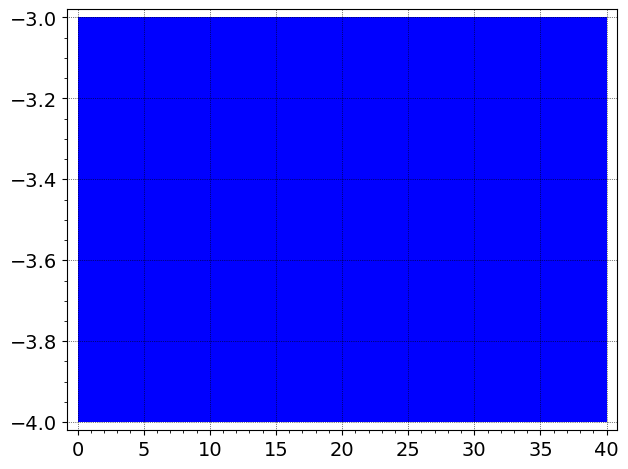

In [130]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("15.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa31d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
a31d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='blue',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=120)
show(a31d2,aspect_ratio='automatic')

Automated checks:
The sum of weighted coefficients is  : 0.4971207781883141 = Xi(0) = 0.4971207781883141 (should be equal).
d/dr z_1(0) via Newton approximation : 11143962.488101 versus formula: 24.916536 (should be close).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


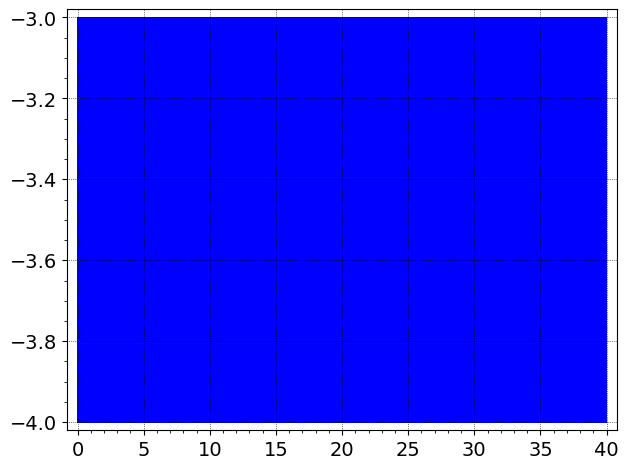

In [149]:
var("r","t");

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("16.5")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("LagCoeffa33d2.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + CCF(alpha+k+1).gamma()/(CCF(alpha+1).gamma() * RDF(k+1).gamma())* RDF(row)
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t * t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    tr = CCF(t) / (CCF(0,1)*CCF(r))
    rr = CCF(r)*CCF(0,1)
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(rr).pow(2*n)*CCF(str(m1[n]))*LagPol(tr,n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,I)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, I)-Xi(60)))
a33d2=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,40),(r,-4,-3),color='blue',fontsize=14,linestyle ="-",linewidth=1,gridlines=True,plot_points=300)
show(a33d2,aspect_ratio='automatic')

In [157]:
import numpy as np
from scipy.integrate import quad
from scipy.special import ive

# --- 1. Define Test Parameters ---
alpha = 1.0
r = exp(-0.6)
y = 2
dy = 1e-5 

def f(x):
    # np.sinc(z) calculates sin(pi*z) / (pi*z)
    # By passing x / (2*np.pi), the pi's cancel out leaving sin(x/2) / (x/2)
    return np.sinc(x / (2 * np.pi))

# --- 2. Define the Numerically Stable Integrands ---
def integrand_numerator(x, y_val):
    # Simplified powers: (xyr)^-(alpha+1) * x^(2alpha+3) = (yr)^-(alpha+1) * x^(alpha+2)
    poly_term = ((y_val * r)**(-(alpha + 1))) * (x**(alpha + 2)) / (1 - r**2)
    z = 2 * x * y_val * r / (1 - r**2)
    
    # Combined perfect-square exponential prevents inf * 0
    exp_term = np.exp(-(x - y_val*r)**2 / (1 - r**2))
    
    # Using ive() instead of iv()
    return f(x) * poly_term * exp_term * ive(alpha + 1, z)

def integrand_denominator(x, y_val):
    # Simplified powers: (xyr)^-alpha * x^(2alpha+1) = (yr)^-alpha * x^(alpha+1)
    poly_term = ((y_val * r)**(-alpha)) * (x**(alpha + 1)) / (1 - r**2)
    z = 2 * x * y_val * r / (1 - r**2)
    
    exp_term = np.exp(-(x - y_val*r)**2 / (1 - r**2))
    return f(x) * poly_term * exp_term * ive(alpha, z)

def integrand_D_simplified(x, y_val):
    z = 2 * x * y_val * r / (1 - r**2)
    # The exponential combined with +z from ive() scaling
    exp_arg = (-x**2 + 2*x*y_val*r) / (1 - r**2)
    
    return f(x) * np.exp(exp_arg) * (x**(alpha + 1)) * ive(alpha, z)

# --- 3. Compute Integrals ---
N_int, _ = quad(integrand_numerator, 0, np.inf, args=(y,))
F_int, _ = quad(integrand_denominator, 0, np.inf, args=(y,))

F_int_plus, _ = quad(integrand_denominator, 0, np.inf, args=(y + dy,))
F_int_minus, _ = quad(integrand_denominator, 0, np.inf, args=(y - dy,))

D_int, _ = quad(integrand_D_simplified, 0, np.inf, args=(y,))
D_int_plus, _ = quad(integrand_D_simplified, 0, np.inf, args=(y + dy,))
D_int_minus, _ = quad(integrand_D_simplified, 0, np.inf, args=(y - dy,))

# --- 4. Calculate Ratios ---
R_original = N_int / F_int

dD_dy = (D_int_plus - D_int_minus) / (2 * dy)
log_deriv_D = dD_dy / D_int
R_simp_D = ((1 - r**2) / (2 * y * r**2)) * (log_deriv_D - alpha/y)

dF_dy = (F_int_plus - F_int_minus) / (2 * dy)
log_deriv_F = dF_dy / F_int
R_simp_F = ((1 - r**2) / (2 * y * r**2)) * log_deriv_F + 1

# --- 5. Output Results ---
print(f"1. Original Integral Ratio : {R_original:.10f}")
print(f"2. Simplified using D(y)   : {R_simp_D:.10f}")
print(f"3. Simplified using F(y)   : {R_simp_F:.10f}")
print("-" * 45)
print(f"Difference (Orig vs Final) : {abs(R_original - R_simp_F):.2e}")

1. Original Integral Ratio : 0.9700975259
2. Simplified using D(y)   : 0.9700975261
3. Simplified using F(y)   : 0.9700975259
---------------------------------------------
Difference (Orig vs Final) : 5.94e-12


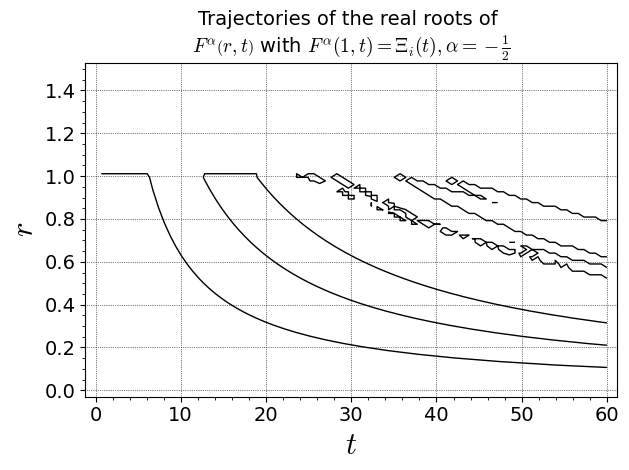

In [242]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y', 'x', 'r', 't')
ord = []
for y in range(6):
    ord.append([2*pi()*(y+1),1])
    ord.append([-2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(200)
RDF=RealBallField(1024)

#set alpha once here:
global alpha
alpha = CCF("-0.5")

def Xin(t):
    Xin= 2 * CCF(t / 2).sin() / CCF(t)
    Zer= (1-t/(1/10000+30*CCF(0,1)))*(1-t/(1/10000-30*CCF(0,1)))*(1-t/(-1/10000+30*CCF(0,1)))*(1-t/(-1/10000-30*CCF(0,1)))
    return Xin

def Wei(x):
    return (-1*(x.pow(2))).exp() * (x).pow(2 * alpha + 1)

def Onemr2(w):
    return (1-w.pow(2))

def PoiKer(y,x,r):
    f1 = 2 * ((x*y*r).pow(2)).pow(-alpha/2) / Onemr2(r)
    f2 = ((-1 * (x.pow(2) + y.pow(2)) * r.pow(2)) / Onemr2(r)).exp()
    f3 = ((2 * x * y * r) / Onemr2(r)).bessel_I(alpha)
    return f1 * f2 * f3

def LaguerreFlow(t, r):
    tt = CCF(t) 
    rr = CCF(r)
    res= CCF.integral(lambda x, _: Xin(x) * PoiKer(tt,x,rr) * Wei(x), CCF("0.00000000000000001"), 21)
    return real_part(res.mid())

am12i=implicit_plot(lambda t,r:(LaguerreFlow(t,r)),(t,0,60),(r,0,1.5),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}\left(r,t\right)$ with $F^\alpha(1,t) = \Xi_i(t), \alpha = -\frac{1}{2}$',gridlines=True,plot_points=90)

show(am12i,aspect_ratio='automatic')

Automated checks:
d/dr z_3(0) via Newton approximation : 18.902607 versus formula: 18.902608 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


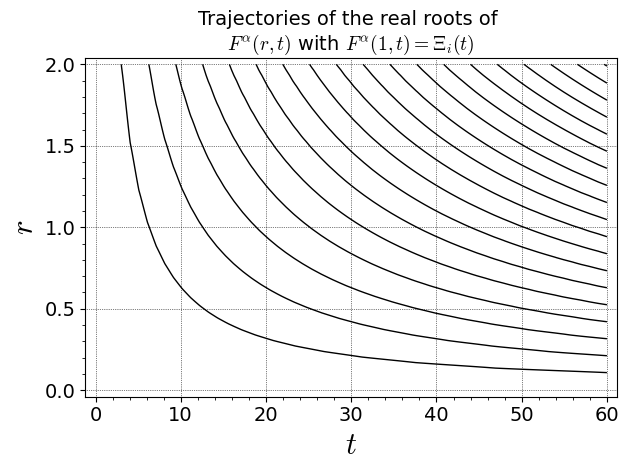

In [238]:
#Laguerre Flow direct evaluation for F = Xi_i

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y','t')
ord = []
for y in range(9):
    ord.append([2*pi()*(y+1),1])
z1=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(53)

#set alpha once here:
global alpha
alpha = CCF("-0.5")

def Xin(t):
    Xin=2 * CCF(t / 2).sin() / CCF(t)
    return Xin

#Laguerre flow closed form for F=Xi_i Humbert Phi_3 series expressed as finite series of 1F1s
CCF=ComplexBallField(200)

def LaguerreFlow(t, r):
    sumn=(CCF(0));
    rho = r
    for n in range(200):
        summandn =  CCF(-1).pow(n) / CCF(2*n+2).gamma() * CCF((CCF(rho).pow(2)-1)/16).hypergeometric([CCF(alpha + n + 1)],[CCF("1.5")+n]) * CCF(CCF(t)*CCF(rho)/2).pow(2*n)
        sumn = sumn + summandn
    return sumn

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0,1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1 * (x1 - 2*k*RDF.pi())/(tr) 
    return dzdr3

#compute d/dr zk via formula
def verifyPDE(k):
    return 1/(2*k*pi())-(CCF(alpha)+CCF("0.5"))/(2*k*pi())+2*k*pi()

print("Automated checks:")
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60,1)-Xin(60)))

a1i1=implicit_plot(lambda t,r:(((LaguerreFlow(t, r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi_i(t)$',gridlines=True,plot_points=60)
show(a1i1,aspect_ratio='automatic')

Automated checks:
d/dr z_1(0) via Newton approximation : 25.536717 versus formula: 25.536267 (should be close).
Ensure 20 digits accuracy at t = 60  : 1.00000000000000000000 (should show 20 zeros).


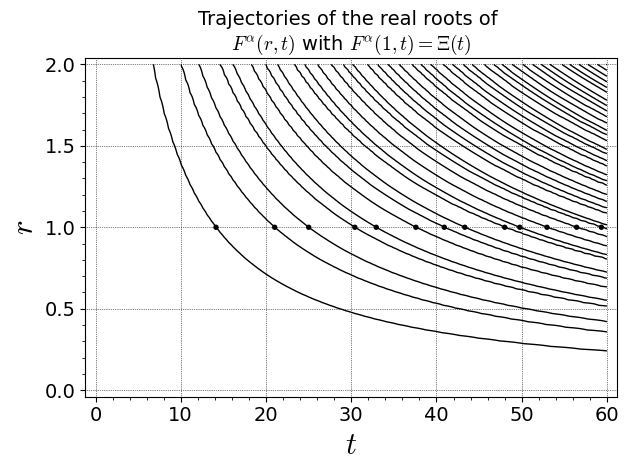

In [55]:
var("r","t");

CCF=ComplexBallField(302)
RDF=RealBallField(302)

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

#set alpha once here (and make sure the coefficient file for this specific alpha is loaded)
global alpha
alpha = CCF("1")

global m1; m1 = []; CoeffSum = RDF(0); 
k = 0
with open("DerivsE0.txt", "r") as f:
    for row in f:
        CoeffSum = CoeffSum + RDF(row) * CCF(k+1).gamma() / CCF(2*k+1).gamma()
        m1.append([RDF(row)])
        k = k + 1
        
def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def LagPol(t,n):
    return CCF(t).laguerre_L(n, alpha)

def LaguerreFlow(t,r):
    sum=CCF(0)
    for n in range(300):
        sum=sum+CCF(str(m1[2*n])) * CCF(n+1).gamma() / CCF(2*n+1).gamma() * CCF(1-r*r).pow(n) * LagPol(t*t*r*r/(r*r-1),n)
    return real_part(sum);

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.00000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = (LaguerreFlow(x0 + tr*100,1+tr) - LaguerreFlow(x0,1+tr))/(tr*100)
        h = LaguerreFlow(x0, 1+tr)/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr3 = -1*(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr3

#sum zeros around k-th zero
def sumzeros(k):
    zk =ordrho[k-1]
    sum0 = 0
    for j in range(k-1):
        sum0 = sum0 + 1/(zk-ordrho[j])
    sum1 = 0
    for j in range(k+1,300001):
        sum1 = sum1 + 1/(zk-ordrho[j-1])
    sum2 = 0
    for j in range(300000):
        sum2 = sum2 + 1/(zk+ordrho[j])
    return sum0 + sum1 + sum2

#compute d/dr zk via formula
def verifyPDE(k):
    return -1*sumzeros(k) - (CCF(alpha).mid() + 1/2)/ordrho[k-1] + ordrho[k-1]

print("Automated checks:")
#print("The sum of weighted coefficients is  : %3.16f = Xi(0) = %3.16f (should be equal)." % (CoeffSum, LaguerreFlow(0,0.9999999999999999999)))
print("d/dr z_1(0) via Newton approximation : %3.6f versus formula: %3.6f (should be close)." % (dzdrzk(3),verifyPDE(3)))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(LaguerreFlow(60, 0.9999999999999999999)/Xi(60)))
a1n=implicit_plot(lambda t,r:((RDF(LaguerreFlow(t,r)))),(t,0,60),(r,0,2),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$','$r$'],title='Trajectories of the real roots of \n' +r'$F^{\alpha}(r,t)$ with $F^\alpha(1,t) = \Xi(t)$',gridlines=True,plot_points=120)
show(a1n+z,aspect_ratio='automatic')